__LRG_OPT and LRG_IR as defined in the original SV1 selection__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS'])
idx = np.where(tmp['TARGETS']=='QSO+LRG')[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

674227
37119


In [4]:
deep = zbest.copy()

# Select deep coadds
mask = deep['subset']=='deep'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Ting-Wen's quality cuts
# mask = deep['DELTACHI2']>20
# mask &= deep['Z']<1.4
# mask &= deep['ZWARN']==0
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# deep = deep[mask]

print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

34868
FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686
18686


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

In [6]:
mask = zbest['RZR']=='single_exposures'
zbest = zbest[mask]
print(len(zbest))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
zbest = zbest[mask]
print(len(zbest))

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

429668
238615
18686


In [7]:
zbest['EXPID'] = np.array(zbest['subset'], dtype=int)

In [8]:
tileid_list = np.unique(zbest['TILEID'])

# stats = Table.read('/global/cfs/cdirs/desi/survey/observations/SV1/sv1-exposures.fits')
stats = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/sv1-exposures_20210315.fits')
print(len(stats))

mask = np.in1d(stats['EXPID'], np.unique(zbest['EXPID']))
stats = stats[mask]
print(len(stats))

stats['fail_frac_lrg_sv'] = -1.
stats['fail_frac_lrg_opt'] = -1.
stats['fail_frac_lrg_ir'] = -1.

stats['n_lrg_sv'] = -1
stats['n_lrg_opt'] = -1
stats['n_lrg_ir'] = -1

stats['deltachi2_ratio'] = -1.

mask_fiber = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)

fail_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > fail_threshold
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0

for tileid in tileid_list:
    
    # print('Tile {}'.format(tileid))
        
    expid_list = np.array(np.unique(zbest['EXPID']))

    for expid in expid_list:
        
        stats_index = np.where(stats['EXPID']==expid)[0][0]
        
        mask_exp = mask_fiber & (zbest['EXPID']==expid)
        mask_exp_fail = mask_exp & mask_fail

        stats['fail_frac_lrg_sv'][stats_index] = np.sum(mask_exp_fail) / np.sum(mask_exp)
        stats['fail_frac_lrg_opt'][stats_index] = np.sum(mask_exp_fail & lrg_opt) / np.sum(mask_exp & lrg_opt)
        stats['fail_frac_lrg_ir'][stats_index] = np.sum(mask_exp_fail & lrg_ir) / np.sum(mask_exp & lrg_ir)        
        stats['n_lrg_sv'][stats_index] = np.sum(mask_exp)
        stats['n_lrg_opt'][stats_index] = np.sum(mask_exp & lrg_opt)
        stats['n_lrg_ir'][stats_index] = np.sum(mask_exp & lrg_ir)
        
        mask_deltachi2 = zbest['DELTACHI2_deep']>100. # quality cut
        stats['deltachi2_ratio'][stats_index] = np.median((zbest['DELTACHI2']/(zbest['DELTACHI2_deep']/zbest['EFFTIME_DARK_deep']*1000))[mask_exp & mask_deltachi2])

1516
176


In [9]:
stats.write('/global/cscratch1/sd/rongpu/desi/sv1/single_exp_coadd_cascades/lrg_redshift_efficiency_sv1_selection.fits', overwrite=True)

In [10]:
stats[:1]

NIGHT,EXPID,FIELD,TARGETS,OBSCONDITIONS,ARIZONA_TIMEOBS,EBV,SPECMODEL_SKY_GFLUX,SPECMODEL_SKY_RFLUX,SPECMODEL_SKY_ZFLUX,GFA_ORIGIN,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,EFFTIME_DARK,EFFTIME_BRIGHT,EFFTIME_BACKUP,SPEED_DARK,SPEED_BRIGHT,SPEED_BACKUP,SPECPROD,SPECPROD_BITPSFFN,SPECPROD_BITFRAMEFN,SPECPROD_BITSKYFN,SPECPROD_BITSFRAMEFN,SPECPROD_BITFLUXCALIBFN,SPECPROD_BITCFRAMEFN,TSNR2_BGS,TSNR2_LRG,TSNR2_ELG,TSNR2_QSO,TILEID,TILERA,TILEDEC,EXPTIME,MJDOBS,N_ASSGN_TGT,N_ASSGN_SKY,N_ASSGN_STD,N_ASSGN_WD,N_ASSGN_LRG,N_ASSGN_ELG,N_ASSGN_QSO,N_ASSGN_BGS,N_ASSGN_MWS,SKYMON_NEXP,SKYMON_SKYCAM0_MEAN,SKYMON_SKYCAM0_MEAN_ERR,SKYMON_SKYCAM1_MEAN,SKYMON_SKYCAM1_MEAN_ERR,SKYMON_AVERAGE_MEAN,SKYMON_AVERAGE_MEAN_ERR,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_FIBER_FRACFLUX_BGS,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_FRACFLUX_NOMINAL_POINTSOURCE,GFA_FRACFLUX_NOMINAL_ELG,GFA_FRACFLUX_NOMINAL_BGS,GFA_RADPROF_FWHM_ASEC,GFA_FIBERFAC,GFA_FIBERFAC_ELG,EPHEM_NOON,EPHEM_DUSK,EPHEM_DAWN,EPHEM_BRIGHTDUSK,EPHEM_BRIGHTDAWN,EPHEM_BRIGHTDUSK_LST,EPHEM_BRIGHTDAWN_LST,EPHEM_MOONRISE,EPHEM_MOONSET,EPHEM_MOON_ILLUM_FRAC,EPHEM_NEAREST_FULL_MOON,fail_frac_lrg_sv,fail_frac_lrg_opt,fail_frac_lrg_ir,n_lrg_sv,n_lrg_opt,n_lrg_ir,deltachi2_ratio
,,,,"1=DARK, 2=GRAY, 4=BRIGHT, -1=ELSE",,,nMgy / arcsec ** 2,nMgy / arcsec ** 2,nMgy / arcsec ** 2,,seconds,seconds,seconds,seconds,seconds,seconds,seconds,seconds,seconds,,,,,,,,,,,,,,,,,,seconds,,,,,,,,,,,,flux units from the database,flux units from the database,flux units from the database,flux units from the database,flux units from the database,flux units from the database,,,,,,,,for an 1.52 arcsecond diameter aperture size,for an 1.52 arcsecond diameter aperture size,for an 1.52 arcsecond diameter aperture size,for an 1.52 arcsecond diameter aperture size,,,,for an 1.52 arcsecond diameter aperture size,for an 1.52 arcsecond diameter aperture size,for an 1.52 arcsecond diameter aperture size,,,,,,,,,,,,,,,,,,,,,
int64,int64,bytes30,bytes16,int16,bytes19,float32,float32,float32,float32,bytes13,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes8,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,int64,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64
20201214,67710,XMM-LSS,QSO+LRG,1,2020-12-14T21:12:40,0.026,1.3076847,3.2340524,17.434511,matched_coadd,20.2,18.1,19.5,15.788471,15.534268,17.904373,28.792017,40.904728,17.60517,0.039467085,0.056446712,0.024602938,cascades,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,144.39601,1.5602673,2.2952428,0.56132203,80605,36.448,-4.601,900.0,59198.176,4200,800,136,13,2117,1341,1428,464,191,0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,1.2455698,0.0036080289,133.7576,119.15718,0.8552955,3.5648782,20.274342,0.09934509,0.091754176,0.050551772,0.0849694,4.109576,3.6593802,0.114,0.58176816,0.42423388,0.19544029,3.7471519,0.1318288,0.16755259,59197.791666666664,59198.07704947222,59198.53638188851,59198.05633958238,59198.557098368896,-7.152731532294979,173.61402820025236,59197.59470830986,59198.02745986081,0.005432771706774475,14.852906347514363,0.7459128065395095,0.6263157894736842,0.5766423357664233,1468,380,411,0.03824481655884196


In [11]:
# mask = stats['fail_frac_lrg_sv']!=-1
# print(np.sum(~mask))
# stats = stats[mask]

__Full depth range__

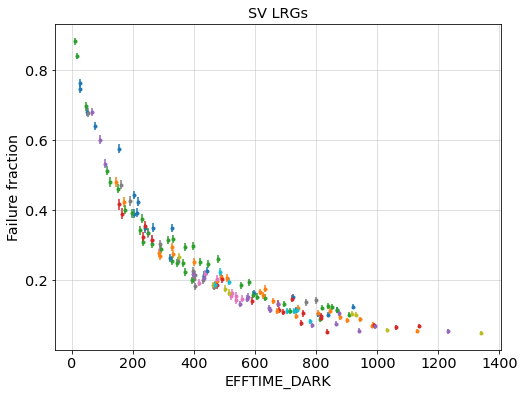

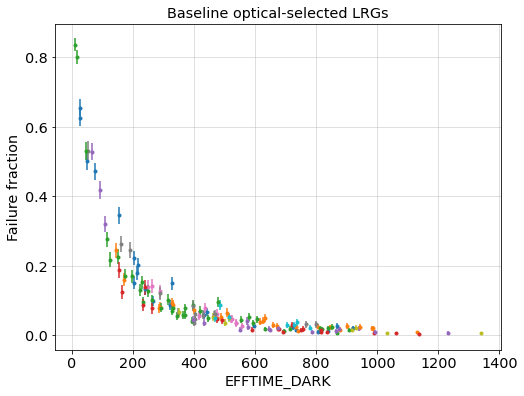

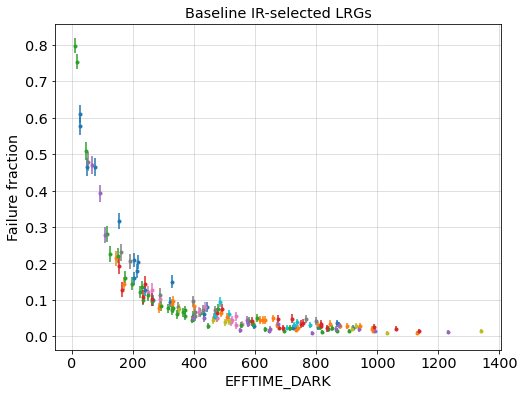

In [12]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('Baseline IR-selected LRGs')
plt.show()

__Only exposures with R_DEPTH_EBVAIR>250__

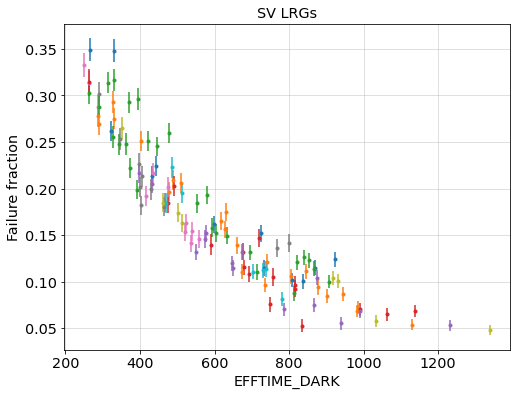

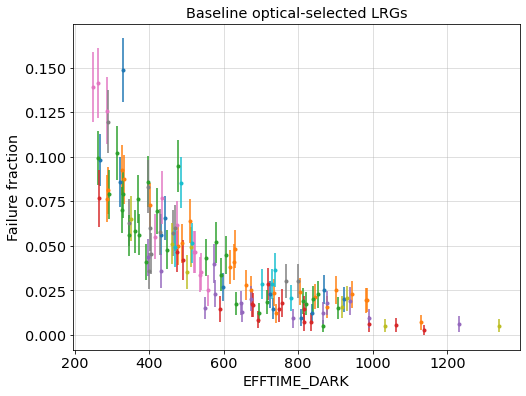

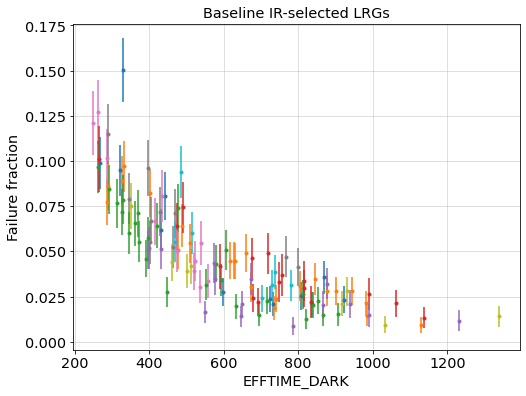

In [13]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('Baseline IR-selected LRGs')
plt.show()

__Same axis limits__

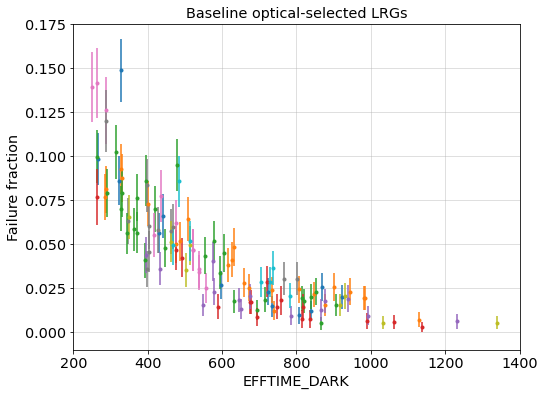

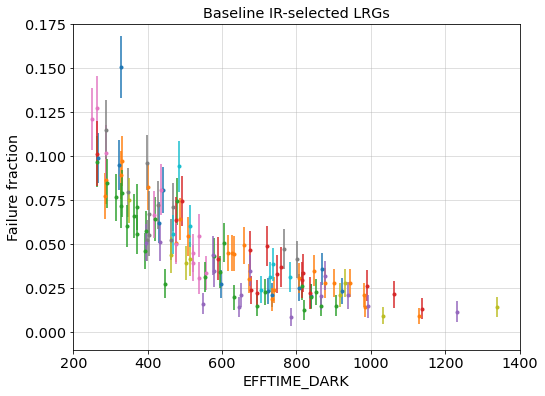

In [14]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.axis([200, 1400, -0.01, 0.175])
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.axis([200, 1400, -0.01, 0.175])
plt.title('Baseline IR-selected LRGs')
plt.show()

__TSNR__

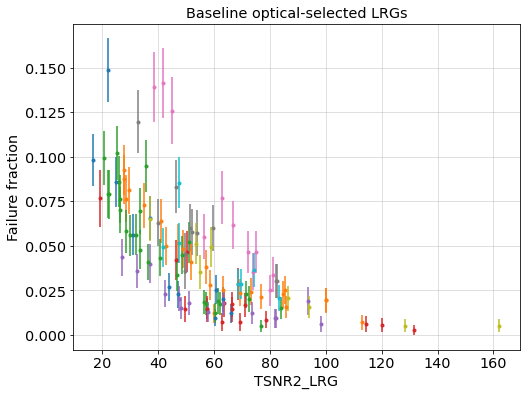

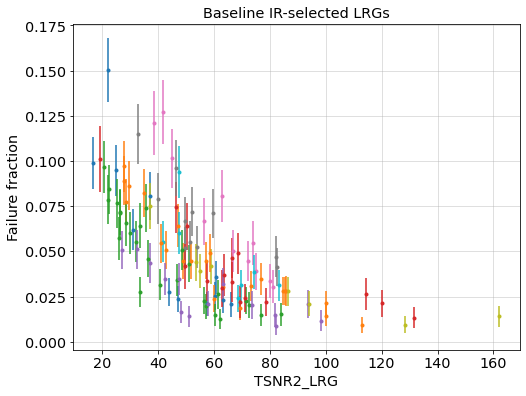

In [15]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['TSNR2_LRG'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('TSNR2_LRG')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
# plt.axis([200, 1400, -0.01, 0.175])
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['TSNR2_LRG'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('TSNR2_LRG')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
# plt.axis([200, 1400, -0.01, 0.175])
plt.title('Baseline IR-selected LRGs')
plt.show()

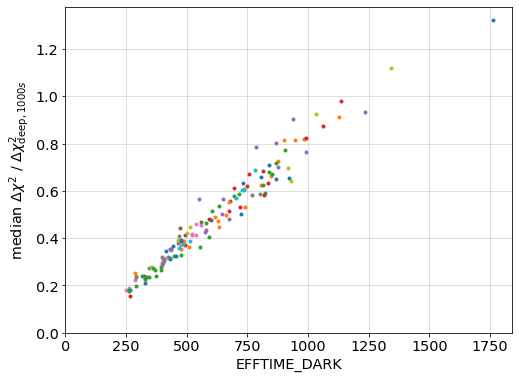

In [16]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250)
    plt.plot((stats['EFFTIME_DARK'])[mask], stats['deltachi2_ratio'][mask], '.', label=tileid)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('median $\Delta\chi^2 \ / \ \Delta\chi_{\mathrm{deep},1000s}^2$')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.grid(alpha=0.5)
# plt.legend(loc='upper left')
plt.show()

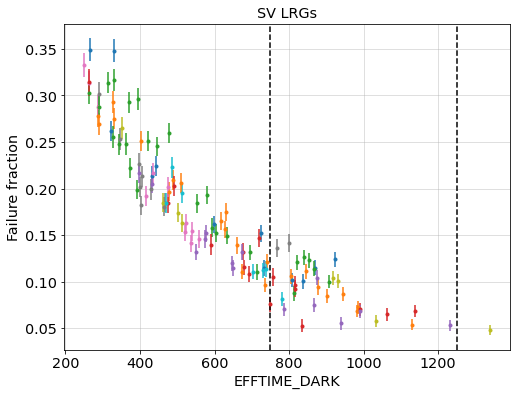

In [17]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['EFFTIME_DARK']>250) & (stats['n_lrg_sv']>500)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['EFFTIME_DARK'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.axvline(750, ls='--', color='k')
plt.axvline(1250, ls='--', color='k')
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()